# 02b — SBI Preprocessing

This notebook creates the real-source frame and facial-metadata triplets used by E3a, E3b and E3c.

```text
dataset/{train,val}/real/*.jpg
        → preserve the existing video-level split
        → RetinaFace detections + 81-point landmarks
        → sbi_dataset/{train,val}/{frames,retina,landmarks}/real/{video_id}/
```

It does **not** create another train/validation split, return to the original videos, or save permanent SBI fake images. SBI real/fake pairs are generated dynamically in memory during training.

## 1. Controls

Existing complete frame/RetinaFace/landmark triplets are skipped, so an interrupted run can resume safely. There is no automatic deletion or force-rebuild option.

In [ ]:
INSTALL_DEPENDENCIES = True
RUN_SBI_DATASET_BUILD = True
RUN_SBI_DATASET_AUDIT = True
RUN_SBI_SAMPLE_VISUAL_CHECK = False

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

print("Install SBI preprocessing dependencies:", INSTALL_DEPENDENCIES)
print("Build sbi_dataset:", RUN_SBI_DATASET_BUILD)
print("Audit sbi_dataset:", RUN_SBI_DATASET_AUDIT)

Install SBI preprocessing dependencies: True
Build sbi_dataset: True
Audit sbi_dataset: True


## 2. Mount Drive and restore preprocessing dependencies

The official SBI repository supplies utility code used later by the training notebooks. The 81-point dlib predictor supplies the dense landmarks required to construct SBI masks.

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

if INSTALL_DEPENDENCIES:
    import subprocess
    import sys
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q",
        "retina-face", "tf-keras", "imutils",
    ])

import json
import subprocess
import time
import urllib.request
from pathlib import Path

import cv2
import dlib
import numpy as np
import pandas as pd
from imutils import face_utils
from retinaface import RetinaFace

BASE_PATH = Path("/content/drive/MyDrive/deepfake_project")
DATASET_ROOT = BASE_PATH / "dataset"
SBI_ROOT = BASE_PATH / "sbi_dataset"
RESULTS_ROOT = BASE_PATH / "results"
SPLIT_MANIFEST_PATH = BASE_PATH / "ffpp_video_split_manifest.json"

OFFICIAL_REPOSITORY = Path("/content/SelfBlendedImages")
PREDICTOR_PATH = (
    OFFICIAL_REPOSITORY / "src" / "preprocess"
    / "shape_predictor_81_face_landmarks.dat"
)

if not SPLIT_MANIFEST_PATH.exists():
    raise FileNotFoundError(
        "The FF++ video-level split manifest is missing. Run the combined "
        "setup and data-preparation notebook first."
    )

if not OFFICIAL_REPOSITORY.is_dir():
    subprocess.run([
        "git", "clone",
        "https://github.com/mapooon/SelfBlendedImages.git",
        str(OFFICIAL_REPOSITORY),
    ], check=True)

if not PREDICTOR_PATH.is_file():
    PREDICTOR_PATH.parent.mkdir(parents=True, exist_ok=True)
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/codeniko/"
        "shape_predictor_81_face_landmarks/master/"
        "shape_predictor_81_face_landmarks.dat",
        str(PREDICTOR_PATH),
    )

RESULTS_ROOT.mkdir(parents=True, exist_ok=True)

print("Input dataset:", DATASET_ROOT)
print("SBI output:", SBI_ROOT)
print("Official SBI repository:", OFFICIAL_REPOSITORY)
print("81-point predictor:", PREDICTOR_PATH)

Mounted at /content/drive
Input dataset: /content/drive/MyDrive/deepfake_project/dataset
SBI output: /content/drive/MyDrive/deepfake_project/sbi_dataset
Official SBI repository: /content/SelfBlendedImages
81-point predictor: /content/SelfBlendedImages/src/preprocess/shape_predictor_81_face_landmarks.dat


## 3. Verify the exact real source frames

Official and adapted SBI training generate synthetic fakes from genuine real frames. Only the clean split's real training and validation frames are therefore prepared here.

In [ ]:
def list_images(folder):
    if not folder.is_dir():
        return []
    return sorted(
        path for path in folder.iterdir()
        if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
    )


def recover_video_id(filename):
    stem = Path(filename).stem
    if "_frame_" not in stem:
        raise ValueError(f"Cannot recover video id from: {filename}")
    return stem.rsplit("_frame_", 1)[0]


input_frames = {}
input_rows = []
input_video_ids = {}

for split in ("train", "val"):
    folder = DATASET_ROOT / split / "real"
    frames = list_images(folder)
    input_frames[split] = frames
    video_ids = {recover_video_id(path.name) for path in frames}
    input_video_ids[split] = video_ids
    input_rows.append({
        "split": split,
        "class": "real",
        "input_frames": len(frames),
        "source_videos": len(video_ids),
        "folder_exists": folder.is_dir(),
    })

input_table = pd.DataFrame(input_rows)
display(input_table)

if not input_table["folder_exists"].all():
    raise FileNotFoundError("A required real FF++ split folder is missing.")
if (input_table["input_frames"] == 0).any():
    raise RuntimeError("A required real FF++ split folder is empty.")
if input_video_ids["train"] & input_video_ids["val"]:
    raise RuntimeError("Training/validation video overlap exists before SBI preprocessing.")

print("Real SBI source frames are ready with no train/validation video overlap.")

,split,class,input_frames,source_videos,folder_exists
0,train,real,1400,140,True
1,val,real,300,30,True


Real SBI source frames are ready with no train/validation video overlap.


## 4. RetinaFace and 81-landmark extraction

For every prepared frame, all RetinaFace detections are stored with the largest first. The largest face box is used for the dlib 81-point landmark predictor. Coordinates remain aligned with the unchanged full frame.

In [ ]:
face_predictor = dlib.shape_predictor(str(PREDICTOR_PATH))


def extract_face_metadata(frame_bgr):
    frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)

    try:
        detections = RetinaFace.detect_faces(frame_rgb)
    except Exception as error:
        return None, None, f"retinaface error: {error}"

    if not isinstance(detections, dict):
        return None, None, "no face detected"

    retina_entries = []
    areas = []
    for detection in detections.values():
        facial_area = detection.get("facial_area")
        landmarks = detection.get("landmarks")
        if facial_area is None or landmarks is None:
            continue

        x1, y1, x2, y2 = map(float, facial_area)
        retina_points = np.asarray([
            [x1, y1],
            [x2, y2],
            landmarks["left_eye"],
            landmarks["right_eye"],
            landmarks["nose"],
            landmarks["mouth_left"],
            landmarks["mouth_right"],
        ], dtype=np.float32)
        retina_entries.append(retina_points)
        areas.append(max(0.0, x2 - x1) * max(0.0, y2 - y1))

    if not retina_entries:
        return None, None, "no valid face metadata"

    order = np.argsort(np.asarray(areas))[::-1]
    retina_array = np.asarray(retina_entries, dtype=np.float32)[order]

    x1, y1 = retina_array[0][0]
    x2, y2 = retina_array[0][1]
    height, width = frame_rgb.shape[:2]
    x1 = int(np.clip(x1, 0, width - 1))
    y1 = int(np.clip(y1, 0, height - 1))
    x2 = int(np.clip(x2, x1 + 1, width))
    y2 = int(np.clip(y2, y1 + 1, height))

    try:
        rectangle = dlib.rectangle(x1, y1, x2, y2)
        shape = face_predictor(frame_rgb, rectangle)
        landmark_array = face_utils.shape_to_np(shape).astype(np.float32)
    except Exception as error:
        return None, None, f"landmark error: {error}"

    if landmark_array.shape != (81, 2):
        return None, None, f"unexpected landmark shape: {landmark_array.shape}"

    return retina_array, landmark_array[None, ...], "success"

## 5. Build or safely resume `sbi_dataset`

Each source frame is stored as PNG inside its source-video folder. The corresponding RetinaFace and landmark arrays use the same stem. A sample is skipped only when all three files already exist.

In [ ]:
if RUN_SBI_DATASET_BUILD:
    build_rows = []
    start_time = time.time()

    for split in ("train", "val"):
        frames_root = SBI_ROOT / split / "frames" / "real"
        retina_root = SBI_ROOT / split / "retina" / "real"
        landmarks_root = SBI_ROOT / split / "landmarks" / "real"

        print(f"Processing SBI {split}/real: {len(input_frames[split])} frames")

        for position, input_path in enumerate(input_frames[split], start=1):
            video_id = recover_video_id(input_path.name)
            output_stem = input_path.stem
            frame_path = frames_root / video_id / f"{output_stem}.png"
            retina_path = retina_root / video_id / f"{output_stem}.npy"
            landmark_path = landmarks_root / video_id / f"{output_stem}.npy"

            if frame_path.exists() and retina_path.exists() and landmark_path.exists():
                status = "already existed"
                faces_detected = None
            else:
                frame_bgr = cv2.imread(str(input_path))
                if frame_bgr is None:
                    status = "unreadable input"
                    faces_detected = 0
                else:
                    retina_array, landmark_array, status = extract_face_metadata(frame_bgr)
                    faces_detected = 0 if retina_array is None else len(retina_array)

                    if status == "success":
                        frame_path.parent.mkdir(parents=True, exist_ok=True)
                        retina_path.parent.mkdir(parents=True, exist_ok=True)
                        landmark_path.parent.mkdir(parents=True, exist_ok=True)

                        frame_saved = cv2.imwrite(str(frame_path), frame_bgr)
                        if not frame_saved:
                            status = "frame write failed"
                        else:
                            np.save(retina_path, retina_array)
                            np.save(landmark_path, landmark_array)
                            status = "saved"

            build_rows.append({
                "split": split,
                "class": "real",
                "video_id": video_id,
                "input_filename": input_path.name,
                "output_stem": output_stem,
                "status": status,
                "faces_detected": faces_detected,
            })

            if position % 100 == 0 or position == len(input_frames[split]):
                print(f"  {position}/{len(input_frames[split])}")

    sbi_build_log = pd.DataFrame(build_rows)
    log_path = RESULTS_ROOT / "sbi_dataset_build_log.csv"
    sbi_build_log.to_csv(log_path, index=False)

    print(f"SBI preprocessing completed in {(time.time() - start_time) / 60:.2f} minutes.")
    display(
        sbi_build_log.groupby(["split", "class", "status"])
        .size().rename("frames").reset_index()
    )
    print("Build log:", log_path)
else:
    print("SBI dataset build skipped.")

Processing SBI train/real: 1400 frames
26-08-10 18:36:41 - Directory /root/.deepface created
26-08-10 18:36:41 - Directory /root/.deepface/weights created
26-08-10 18:36:41 - retinaface.h5 will be downloaded from the url https://github.com/serengil/deepface_models/releases/download/v1.0/retinaface.h5


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/retinaface.h5
To: /root/.deepface/weights/retinaface.h5
100%|██████████| 119M/119M [00:01<00:00, 117MB/s]


  100/1400
  200/1400
  300/1400
  400/1400
  500/1400
  600/1400
  700/1400
  800/1400
  900/1400
  1000/1400
  1100/1400
  1200/1400
  1300/1400
  1400/1400
Processing SBI val/real: 300 frames
  100/300
  200/300
  300/300
SBI preprocessing completed in 14.99 minutes.


,split,class,status,frames
0,train,real,no valid face metadata,58
1,train,real,saved,1342
2,val,real,no valid face metadata,10
3,val,real,saved,290


Build log: /content/drive/MyDrive/deepfake_project/results/sbi_dataset_build_log.csv


## 6. SBI dataset audit

The audit verifies one-to-one frame/RetinaFace/landmark triplets, array shapes, membership in the prepared FF++ split and absence of train/validation video overlap.

In [ ]:
def collect_triplet_keys(root, extension):
    if not root.is_dir():
        return set()
    return {
        (path.parent.name, path.stem)
        for path in root.rglob(f"*{extension}")
        if path.is_file()
    }


if RUN_SBI_DATASET_AUDIT:
    audit_rows = []
    output_video_ids = {}
    all_shape_errors = []

    for split in ("train", "val"):
        frames_root = SBI_ROOT / split / "frames" / "real"
        retina_root = SBI_ROOT / split / "retina" / "real"
        landmarks_root = SBI_ROOT / split / "landmarks" / "real"

        frame_keys = collect_triplet_keys(frames_root, ".png")
        retina_keys = collect_triplet_keys(retina_root, ".npy")
        landmark_keys = collect_triplet_keys(landmarks_root, ".npy")
        complete_keys = frame_keys & retina_keys & landmark_keys

        expected_keys = {
            (recover_video_id(path.name), path.stem)
            for path in input_frames[split]
        }
        unexpected_keys = (frame_keys | retina_keys | landmark_keys) - expected_keys
        output_video_ids[split] = {video_id for video_id, _ in complete_keys}

        for video_id, stem in sorted(complete_keys):
            retina_array = np.load(retina_root / video_id / f"{stem}.npy")
            landmark_array = np.load(landmarks_root / video_id / f"{stem}.npy")
            if retina_array.ndim != 3 or retina_array.shape[1:] != (7, 2):
                all_shape_errors.append(f"retina/{split}/{video_id}/{stem}: {retina_array.shape}")
            if landmark_array.shape != (1, 81, 2):
                all_shape_errors.append(f"landmarks/{split}/{video_id}/{stem}: {landmark_array.shape}")

        audit_rows.append({
            "split": split,
            "input_real_frames": len(expected_keys),
            "frame_files": len(frame_keys),
            "retina_arrays": len(retina_keys),
            "landmark_arrays": len(landmark_keys),
            "complete_triplets": len(complete_keys),
            "source_videos": len(output_video_ids[split]),
            "missing_triplets": len(expected_keys - complete_keys),
            "unexpected_items": len(unexpected_keys),
        })

    sbi_audit_table = pd.DataFrame(audit_rows)
    display(sbi_audit_table)

    overlap = output_video_ids["train"] & output_video_ids["val"]
    sbi_overlap_table = pd.DataFrame([{
        "comparison": "train vs val",
        "overlapping_videos": len(overlap),
        "examples": sorted(overlap)[:5],
    }])
    display(sbi_overlap_table)

    if (sbi_audit_table["complete_triplets"] == 0).any():
        raise RuntimeError("At least one SBI split contains no complete triplets.")
    if (sbi_audit_table["unexpected_items"] > 0).any():
        raise RuntimeError("Unexpected SBI items do not match the prepared input split.")
    if all_shape_errors:
        raise RuntimeError(f"Invalid SBI metadata shapes found: {all_shape_errors[:5]}")
    if overlap:
        raise RuntimeError("Source-video overlap was detected in the SBI dataset.")

    print("PASS: SBI triplets match the clean train/validation video split.")
else:
    print("SBI dataset audit skipped.")

,split,input_real_frames,frame_files,retina_arrays,landmark_arrays,complete_triplets,source_videos,missing_triplets,unexpected_items
0,train,1400,1342,1342,1342,1342,140,58,0
1,val,300,290,290,290,290,30,10,0


,comparison,overlapping_videos,examples
0,train vs val,0,[]


PASS: SBI triplets match the clean train/validation video split.


## 7. Optional visual check

This displays one saved frame with the largest RetinaFace box, five RetinaFace landmarks and all 81 dlib landmarks.

In [ ]:
RUN_SBI_SAMPLE_VISUAL_CHECK=True

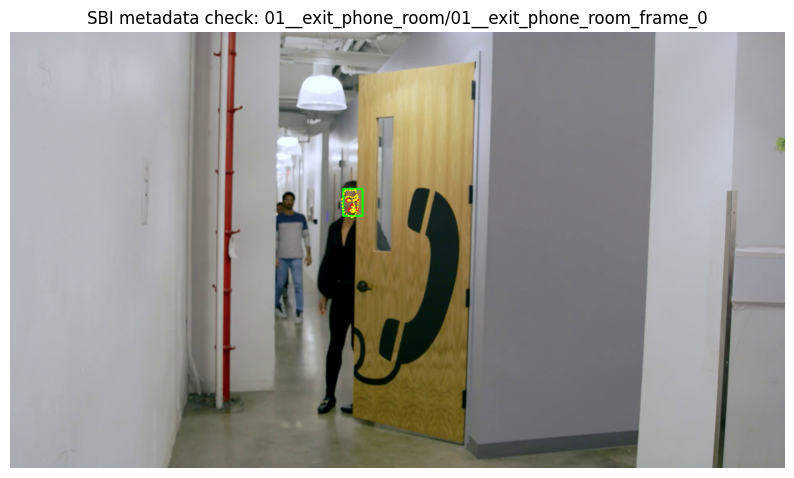

In [ ]:
if RUN_SBI_SAMPLE_VISUAL_CHECK:
    import matplotlib.pyplot as plt

    frames_root = SBI_ROOT / "train" / "frames" / "real"
    frame_paths = sorted(frames_root.rglob("*.png"))
    if not frame_paths:
        raise RuntimeError("No SBI frames are available for visual inspection.")

    frame_path = frame_paths[0]
    video_id = frame_path.parent.name
    stem = frame_path.stem
    retina_path = SBI_ROOT / "train" / "retina" / "real" / video_id / f"{stem}.npy"
    landmark_path = SBI_ROOT / "train" / "landmarks" / "real" / video_id / f"{stem}.npy"

    frame_bgr = cv2.imread(str(frame_path))
    frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
    retina_array = np.load(retina_path)
    landmark_array = np.load(landmark_path)
    annotated = frame_rgb.copy()

    largest = retina_array[0]
    x1, y1 = largest[0].astype(int)
    x2, y2 = largest[1].astype(int)
    cv2.rectangle(annotated, (x1, y1), (x2, y2), (0, 255, 0), 3)
    for x, y in largest[2:]:
        cv2.circle(annotated, (int(x), int(y)), 5, (255, 0, 0), -1)
    for x, y in landmark_array[0]:
        cv2.circle(annotated, (int(x), int(y)), 2, (255, 255, 0), -1)

    plt.figure(figsize=(10, 8))
    plt.imshow(annotated)
    plt.title(f"SBI metadata check: {video_id}/{stem}")
    plt.axis("off")
    plt.show()
else:
    print("SBI visual check skipped.")

## 8. Downstream notebooks

After the audit passes, run:

- `03f_E3a_Adapted_SBI_Training.ipynb`
- `03g_E3b_Official_SBI_Training.ipynb`
- `03h_E3c_SBI_SAM_Training.ipynb`

These notebooks generate balanced real/SBI-fake pairs dynamically. They do not require permanent fake preprocessing folders.